In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA


# Load the datasets
customers_df = pd.read_csv(r'C:\Users\WIN-11\Desktop\Zeotap Internship\data\Customers.csv')
products_df = pd.read_csv(r'C:\Users\WIN-11\Desktop\Zeotap Internship\data\Products.csv')
transactions_df = pd.read_csv(r'C:\Users\WIN-11\Desktop\Zeotap Internship\data\Transactions.csv')

# Merge the customers with their transactions to create a profile
transactions_df = transactions_df.merge(customers_df[['CustomerID', 'Region']], on='CustomerID', how='left')

# Feature engineering: Aggregate transaction data by customer
customer_features = transactions_df.groupby('CustomerID').agg(
    total_spent=('TotalValue', 'sum'),
    avg_spent=('TotalValue', 'mean'),
    total_items=('Quantity', 'sum'),
    unique_products=('ProductID', 'nunique'),
    transaction_count=('TransactionID', 'nunique')
).reset_index()

# Normalize the features for clustering
scaler = StandardScaler()
customer_features[['total_spent', 'avg_spent', 'total_items', 'unique_products', 'transaction_count']] = scaler.fit_transform(
    customer_features[['total_spent', 'avg_spent', 'total_items', 'unique_products', 'transaction_count']]
)

# Inspect the data
customer_features.head()


,CustomerID,total_spent,avg_spent,total_items,unique_products,transaction_count
0,C0001,-0.061701,-0.070263,-0.122033,0.050047,-0.011458
1,C0002,-0.877744,-0.934933,-0.448000,-0.424204,-0.467494
2,C0003,-0.405857,-0.026271,0.203934,-0.424204,-0.467494
3,C0004,1.032547,-0.076769,1.670787,1.472798,1.356650
4,C0005,-0.783929,-0.040028,-0.936951,-0.898455,-0.923530


In [6]:
# Function to perform K-Means clustering and calculate evaluation metrics
def perform_clustering(n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    customer_features['Cluster'] = kmeans.fit_predict(customer_features[['total_spent', 'avg_spent', 'total_items', 'unique_products', 'transaction_count']])
    
    # Calculate Davies-Bouldin Index (DBI) and Silhouette Score
    dbi = davies_bouldin_score(customer_features[['total_spent', 'avg_spent', 'total_items', 'unique_products', 'transaction_count']], customer_features['Cluster'])
    silhouette = silhouette_score(customer_features[['total_spent', 'avg_spent', 'total_items', 'unique_products', 'transaction_count']], customer_features['Cluster'])
    
    return kmeans, dbi, silhouette

# Try different values for n_clusters (between 2 and 10) and evaluate
metrics = []
for n_clusters in range(2, 11):
    kmeans, dbi, silhouette = perform_clustering(n_clusters)
    metrics.append((n_clusters, dbi, silhouette))

# Convert the metrics into a DataFrame for easy comparison
metrics_df = pd.DataFrame(metrics, columns=['Number of Clusters', 'DBI', 'Silhouette Score'])
print(metrics_df)


C:\Users\WIN-11\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\WIN-11\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\WIN-11\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\WIN-11\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

   Number of Clusters       DBI  Silhouette Score
0                   2  0.912149          0.404760
1                   3  1.064985          0.308076
2                   4  0.956413          0.329901
3                   5  0.992170          0.302111
4                   6  0.926948          0.329953
5                   7  0.969394          0.302981
6                   8  0.994391          0.302992
7                   9  0.954976          0.311811
8                  10  0.947567          0.307870


C:\Users\WIN-11\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


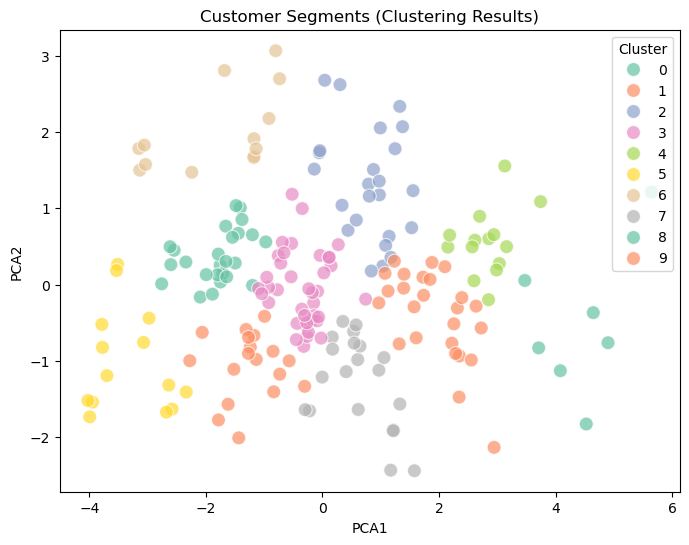

In [4]:

# Use PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
customer_features_pca = pca.fit_transform(customer_features[['total_spent', 'avg_spent', 'total_items', 'unique_products', 'transaction_count']])

# Add PCA components and cluster labels to the DataFrame
customer_features['PCA1'] = customer_features_pca[:, 0]
customer_features['PCA2'] = customer_features_pca[:, 1]

# Visualize the clusters using a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=customer_features, palette='Set2', s=100, alpha=0.7)
plt.title('Customer Segments (Clustering Results)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend(title='Cluster', loc='upper right')
plt.show()


In [7]:
# Add PCA components and cluster labels to the DataFrame
customer_features['PCA1'] = customer_features_pca[:, 0]
customer_features['PCA2'] = customer_features_pca[:, 1]

# Save the customer features with PCA and cluster labels into a CSV file
customer_features.to_csv(r'C:\Users\WIN-11\Desktop\Zeotap Internship\data\customer_segments_with_clusters.csv', index=False)


In [10]:


# 1. Number of clusters formed:
num_clusters = len(customer_features['Cluster'].unique())
print(f"Number of clusters formed: {num_clusters}")

# 2. Calculate Davies-Bouldin Index (DBI):
dbi = davies_bouldin_score(customer_features[['total_spent', 'avg_spent', 'total_items', 'unique_products', 'transaction_count']], customer_features['Cluster'])
print(f"Davies-Bouldin Index (DBI): {dbi:.4f}")

# 3. Calculate Silhouette Score:
sil_score = silhouette_score(customer_features[['total_spent', 'avg_spent', 'total_items', 'unique_products', 'transaction_count']], customer_features['Cluster'])
print(f"Silhouette Score: {sil_score:.4f}")

# Optionally, print the within-cluster sum of squares (Inertia) from KMeans:
# (assuming kmeans object exists from previous steps)
inertia = kmeans.inertia_
print(f"Within-cluster sum of squares (Inertia): {inertia:.4f}")

# Save the results into a DataFrame for a neat report
metrics_report = pd.DataFrame({
    "Metric": ["Number of Clusters", "Davies-Bouldin Index (DBI)", "Silhouette Score", "Inertia"],
    "Value": [num_clusters, dbi, sil_score, inertia]
})


Number of clusters formed: 10
Davies-Bouldin Index (DBI): 0.9476
Silhouette Score: 0.3079
Within-cluster sum of squares (Inertia): 138.3000
